# 1. Synthetic Data Generation & Exploration

Generate synthetic animals using the BE model, visualise behaviour across
learning phases, and build intuition for how parameters shape behaviour.

**Sections:**
1. Setup & imports
2. Single session: model mechanics
3. Parameter sweeps: how each param affects behaviour
4. Multi-session trajectories: naive → expert → shift
5. Cycling design: A→B→A→B with meta-learning
6. Distribution effects: Uniform vs Hard-A vs Hard-B

## 1. Setup

In [ ]:
import sys
import os

sys.path.append(os.path.abspath(".."))

%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import warnings
warnings.filterwarnings('ignore')

# --- Project imports ---
from Models.BE_core import BEParams, BEState, BEModel, ModelTrace
from Models.BE_model import BoundaryEstimationModel
from Helpers.psychometry import fit_psychometric
from Helpers.utils import cumulative_gaussian
from Analysis.summary_stats import compute_summary_stats, list_available_stats, get_stat_names_expanded
from Analysis.update_matrix import compute_update_matrix, compute_update_matrix_from_model_trace
from Data.structures import (
    generate_synthetic_animal, generate_synthetic_session,
    sample_stimuli, stimulus_to_category,
    DistributionEpoch, make_distribution_schedule,
    param_trajectory_naive_to_expert, param_trajectory_full, param_trajectory_cycling,
)

print("Available summary stats:", list_available_stats())

Available summary stats: ['accuracy', 'psychometric', 'recency', 'win_stay', 'win_stay_rate', 'lose_shift', 'choice_autocorr', 'side_bias', 'stimulus_sensitivity', 'choice_entropy', 'perseveration', 'logistic_history', 'hard_easy_ratio', 'hard_accuracy', 'easy_accuracy', 'conditional_psychometric', 'update_matrix', 'binned_accuracy', 'binned_choice_prob']


## 2. Single Session: Model Mechanics

Simulate one session with fixed parameters and visualise:
- Trial-by-trial stimuli and choices
- Belief distribution evolution
- Psychometric curve
- Update matrix

In [ ]:
# --- Configuration ---
PARAMS = dict(sigma_percep=0.15, A_repulsion=0.10, eta_learning=0.1, eta_relax=0.03)
N_TRIALS = 400
BURN_IN = 0
SEED = 42

In [67]:
# --- Simulate ---
model = BoundaryEstimationModel(**PARAMS)
model.reset_belief(burn_in=BURN_IN, burn_in_seed=SEED)

rng = np.random.default_rng(SEED)
stimuli = sample_stimuli(N_TRIALS, 'Uniform', rng)
categories = stimulus_to_category(stimuli)

choices, p_B = model.simulate_session(
    stimuli, categories, rng=rng, store_history=True
)
trace = model.get_model_trace()

correct = (choices == categories)
valid = ~np.isnan(choices)
print(f"Performance: {correct[valid].mean():.1%}")
print(f"Bias (P(B)): {choices[valid].mean():.3f}")

Performance: 77.0%
Bias (P(B)): 0.475


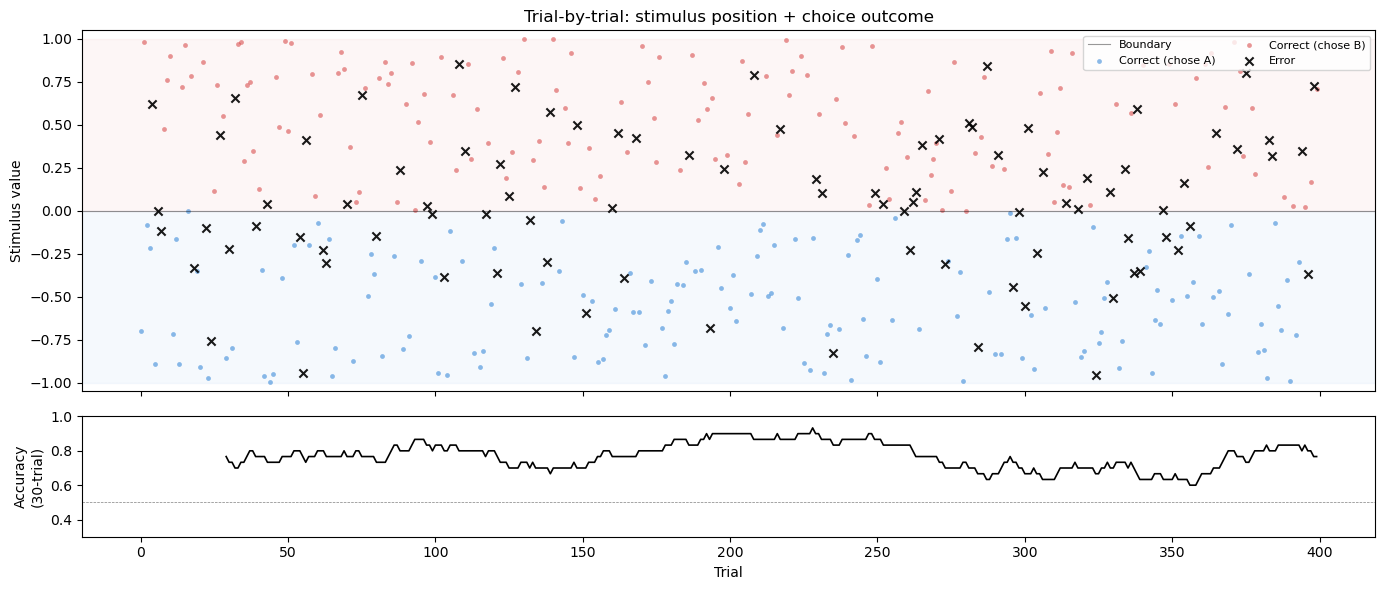

Trials: 400 total, 400 valid, 308 correct (77.0%), 92 errors
Errors near boundary (|stim| < 0.3): 41/92 (45%)


In [69]:
# --- Trial-by-trial view ---
fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True,
                          gridspec_kw={'height_ratios': [3, 1]})

valid = ~np.isnan(choices)
correct = (choices == categories) & valid
incorrect = (~(choices == categories)) & valid
abort = np.isnan(choices)

# Top: stimuli with outcome overlay
ax = axes[0]

# Background shading for categories
ax.axhspan(-1, 0, color='#1976d2', alpha=0.04)
ax.axhspan(0, 1, color='#d32f2f', alpha=0.04)
ax.axhline(0, color='k', linewidth=0.8, linestyle='-', alpha=0.4, label='Boundary')

# Plot each trial as a marker at its stimulus value
# Correct: filled circle, colour matches chosen category
# Incorrect: X marker in red
# Aborts: small grey dot

# Correct trials
correct_chose_A = correct & (choices == 0)
correct_chose_B = correct & (choices == 1)
ax.scatter(np.where(correct_chose_A)[0], stimuli[correct_chose_A],
           s=12, c='#1976d2', marker='o', alpha=0.5, linewidths=0, label='Correct (chose A)')
ax.scatter(np.where(correct_chose_B)[0], stimuli[correct_chose_B],
           s=12, c='#d32f2f', marker='o', alpha=0.5, linewidths=0, label='Correct (chose B)')

# Incorrect trials — prominent
ax.scatter(np.where(incorrect)[0], stimuli[incorrect],
           s=35, c='black', marker='x', alpha=0.9, linewidths=1.5, 
           zorder=3, label='Error')

# Aborts
if abort.any():
    ax.scatter(np.where(abort)[0], stimuli[abort],
               s=8, c='grey', marker='.', alpha=0.3, label='Abort')

ax.set_ylabel('Stimulus value')
ax.set_ylim(-1.05, 1.05)
ax.legend(fontsize=8, loc='upper right', ncol=2)
ax.set_title('Trial-by-trial: stimulus position + choice outcome')

# Bottom: rolling performance
ax = axes[1]
window = 30
perf_valid = correct[valid].astype(float)
rolling = np.convolve(perf_valid, np.ones(window)/window, mode='valid')
trial_idx_valid = np.where(valid)[0]
ax.plot(trial_idx_valid[window-1:], rolling, color='k', linewidth=1.2)
ax.axhline(0.5, color='grey', linewidth=0.5, linestyle='--')
ax.set_ylabel(f'Accuracy\n({window}-trial)')
ax.set_xlabel('Trial')
ax.set_ylim(0.3, 1.0)

plt.tight_layout()
plt.show()

# Print summary
n_valid = valid.sum()
n_correct = correct.sum()
n_errors = incorrect.sum()
print(f"Trials: {N_TRIALS} total, {n_valid} valid, {n_correct} correct ({n_correct/n_valid:.1%}), "
      f"{n_errors} errors")
print(f"Errors near boundary (|stim| < 0.3): "
      f"{(incorrect & (np.abs(stimuli) < 0.3)).sum()}/{n_errors} "
      f"({(incorrect & (np.abs(stimuli) < 0.3)).sum()/max(n_errors,1):.0%})")

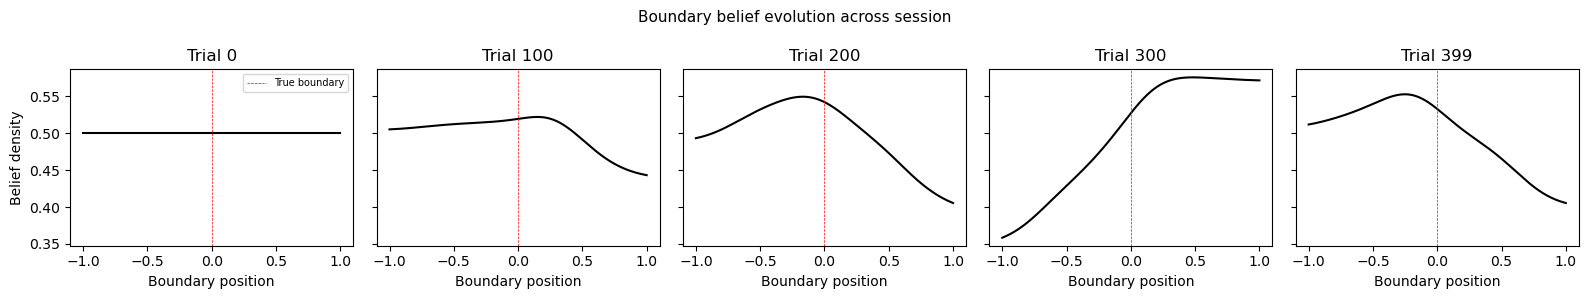

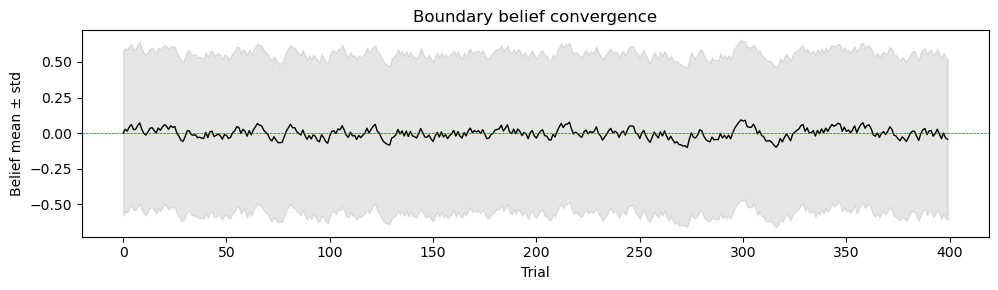

In [70]:
# --- Belief evolution ---
if trace.has_beliefs:
    fig, axes = plt.subplots(1, 5, figsize=(16, 3), sharey=True)
    trial_indices = [0, N_TRIALS//4, N_TRIALS//2, 3*N_TRIALS//4, N_TRIALS-1]
    
    for ax, t_idx in zip(axes, trial_indices):
        ax.plot(trace.x, trace.beliefs[t_idx], 'k-', linewidth=1.5)
        ax.axvline(0, color='red', linewidth=0.5, linestyle='--', label='True boundary')
        ax.set_title(f'Trial {t_idx}')
        ax.set_xlabel('Boundary position')
        if ax == axes[0]:
            ax.set_ylabel('Belief density')
            ax.legend(fontsize=7)
    
    plt.suptitle('Boundary belief evolution across session', fontsize=11)
    plt.tight_layout()
    plt.show()
    
    # Belief mean trajectory
    fig, ax = plt.subplots(figsize=(10, 3))
    ax.plot(trace.belief_means, 'k-', linewidth=1)
    ax.fill_between(
        range(trace.n_trials),
        trace.belief_means - trace.belief_stds,
        trace.belief_means + trace.belief_stds,
        alpha=0.2, color='grey'
    )
    ax.axhline(0, color='red', linewidth=0.5, linestyle='--')
    ax.set_xlabel('Trial')
    ax.set_ylabel('Belief mean ± std')
    ax.set_title('Boundary belief convergence')
    plt.tight_layout()
    plt.show()

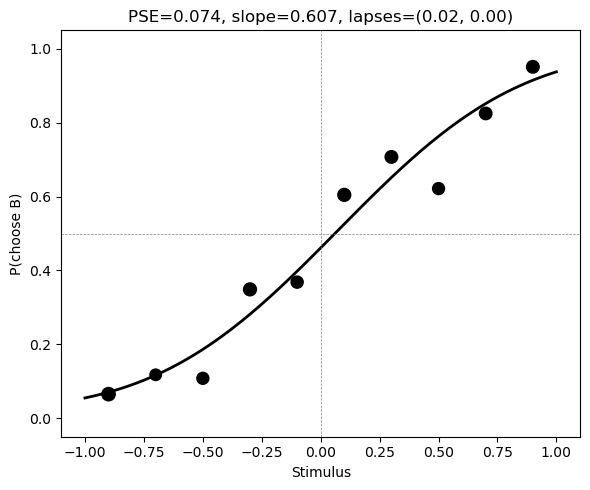

In [71]:
# --- Psychometric curve ---
psych = fit_psychometric(stimuli[valid], choices[valid])

fig, ax = plt.subplots(figsize=(6, 5))

# Bin data
n_bins = 10
bin_edges = np.linspace(-1, 1, n_bins + 1)
mids = (bin_edges[:-1] + bin_edges[1:]) / 2
bin_idx = np.digitize(stimuli[valid], bin_edges) - 1
bin_idx = np.clip(bin_idx, 0, n_bins - 1)

p_B_binned = np.array([choices[valid][bin_idx == b].mean() for b in range(n_bins)])
n_per_bin = np.array([(bin_idx == b).sum() for b in range(n_bins)])

ax.scatter(mids, p_B_binned, s=n_per_bin * 2, c='k', zorder=3)

if psych['success']:
    x_fine = np.linspace(-1, 1, 200)
    y_fit = cumulative_gaussian(x_fine, psych['mu'], psych['sigma'], 
                                 psych['lapse_low'], psych['lapse_high'])
    ax.plot(x_fine, y_fit, 'k-', linewidth=2)
    ax.set_title(f"PSE={psych['mu']:.3f}, slope={psych['sigma']:.3f}, "
                 f"lapses=({psych['lapse_low']:.2f}, {psych['lapse_high']:.2f})")

ax.axhline(0.5, color='grey', linewidth=0.5, linestyle='--')
ax.axvline(0, color='grey', linewidth=0.5, linestyle='--')
ax.set_xlabel('Stimulus')
ax.set_ylabel('P(choose B)')
ax.set_ylim(-0.05, 1.05)
plt.tight_layout()
plt.show()

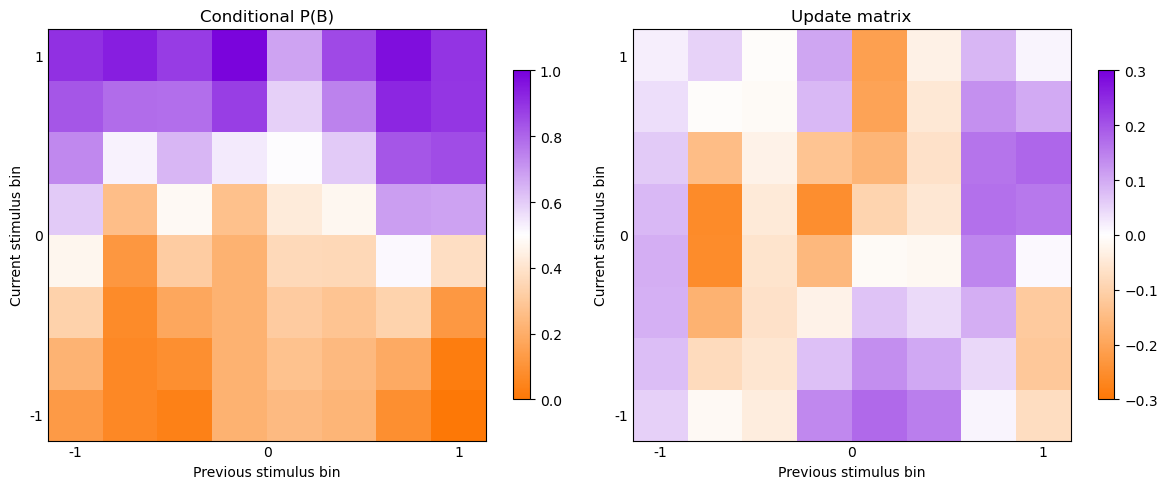

In [81]:
# --- Update matrix ---
import matplotlib.colors as mcolors

# Compute update matrix from trace
update_mat, cond_mat, info = compute_update_matrix_from_model_trace(trace)

# Custom colormap: orange - white - purple
min_color = (253/255, 120/255, 6/255)
mid_color = (1, 1, 1)
max_color = (120/255, 0/255, 220/255)
um_cmap = mcolors.LinearSegmentedColormap.from_list(
    "custom_diverging", [min_color, mid_color, max_color]
)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, mat, title in zip(axes, [cond_mat, update_mat], 
                            ['Conditional P(B)', 'Update matrix']):
    im = ax.imshow(mat, aspect='auto', cmap=um_cmap,
                   vmin=-0.3 if 'Update' in title else 0,
                   vmax=0.3 if 'Update' in title else 1)
    ax.set_xlabel('Previous stimulus bin')
    ax.set_ylabel('Current stimulus bin')
    ax.set_title(title)
    ax.set_xticks([0,3.5,7], [-1,0,1])
    ax.set_yticks([0,3.5,7], [-1,0,1])
    plt.colorbar(im, ax=ax, shrink=0.8)
    ax.invert_yaxis()
    ax.tick_params(axis='both', which='both', length=0)

plt.tight_layout()
plt.show()

## 3. Parameter Sweeps

Vary one parameter at a time while holding others constant.
See how each parameter shapes the psychometric curve and summary stats.

In [74]:
def sweep_parameter(param_name, values, base_params, n_trials=400, burn_in=500, seed=42):
    """Sweep one parameter, return list of (params, choices, stimuli, categories, trace)."""
    results = []
    for val in values:
        p = dict(base_params)
        p[param_name] = val
        
        model = BoundaryEstimationModel(**p)
        model.reset_belief(burn_in=burn_in, burn_in_seed=seed)
        
        rng = np.random.default_rng(seed)
        stim = sample_stimuli(n_trials, 'Uniform', rng)
        cats = stimulus_to_category(stim)
        ch, pB = model.simulate_session(stim, cats, rng=rng, store_history=True)
        
        results.append({
            'value': val,
            'params': p,
            'choices': ch,
            'stimuli': stim,
            'categories': cats,
            'p_B': pB,
            'trace': model.get_model_trace(),
        })
    return results


BASE = dict(sigma_percep=0.15, A_repulsion=0.10, eta_learning=0.30, eta_relax=0.12)

sweeps = {
    'sigma_percep': np.array([0.05, 0.10, 0.15, 0.25, 0.40]),
    'A_repulsion':  np.array([0.0, 0.05, 0.10, 0.20, 0.40]),
    'eta_learning': np.array([0.05, 0.15, 0.30, 0.50, 0.80]),
    'eta_relax':    np.array([0.01, 0.05, 0.12, 0.25, 0.35]),
}

sweep_results = {}
for pname, vals in sweeps.items():
    sweep_results[pname] = sweep_parameter(pname, vals, BASE)
    print(f"  {pname}: done")

  sigma_percep: done
  A_repulsion: done
  eta_learning: done
  eta_relax: done


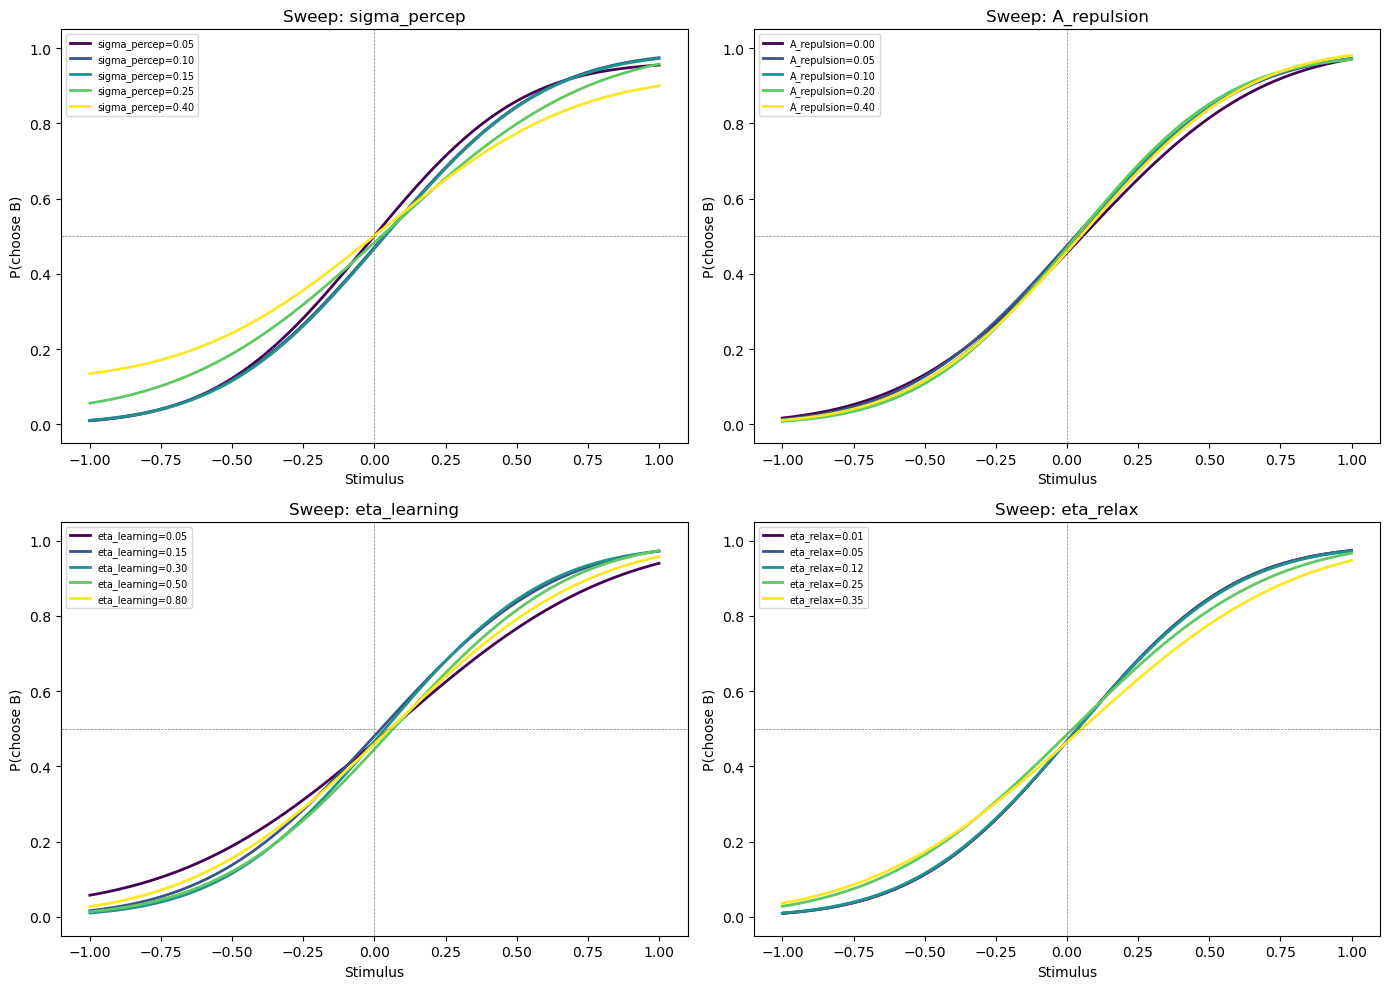

In [75]:
# --- Psychometric curves across sweeps ---
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
x_fine = np.linspace(-1, 1, 200)
cmap = plt.cm.viridis

for ax, pname in zip(axes.flat, sweeps.keys()):
    results = sweep_results[pname]
    vals = sweeps[pname]
    
    for i, res in enumerate(results):
        color = cmap(i / (len(results) - 1))
        valid = ~np.isnan(res['choices'])
        psych = fit_psychometric(res['stimuli'][valid], res['choices'][valid])
        
        if psych['success']:
            y_fit = cumulative_gaussian(x_fine, psych['mu'], psych['sigma'],
                                         psych['lapse_low'], psych['lapse_high'])
            ax.plot(x_fine, y_fit, color=color, linewidth=2, 
                    label=f"{pname}={res['value']:.2f}")
    
    ax.axhline(0.5, color='grey', linewidth=0.5, linestyle='--')
    ax.axvline(0, color='grey', linewidth=0.5, linestyle='--')
    ax.set_xlabel('Stimulus')
    ax.set_ylabel('P(choose B)')
    ax.set_title(f'Sweep: {pname}')
    ax.legend(fontsize=7)
    ax.set_ylim(-0.05, 1.05)

plt.tight_layout()
plt.show()

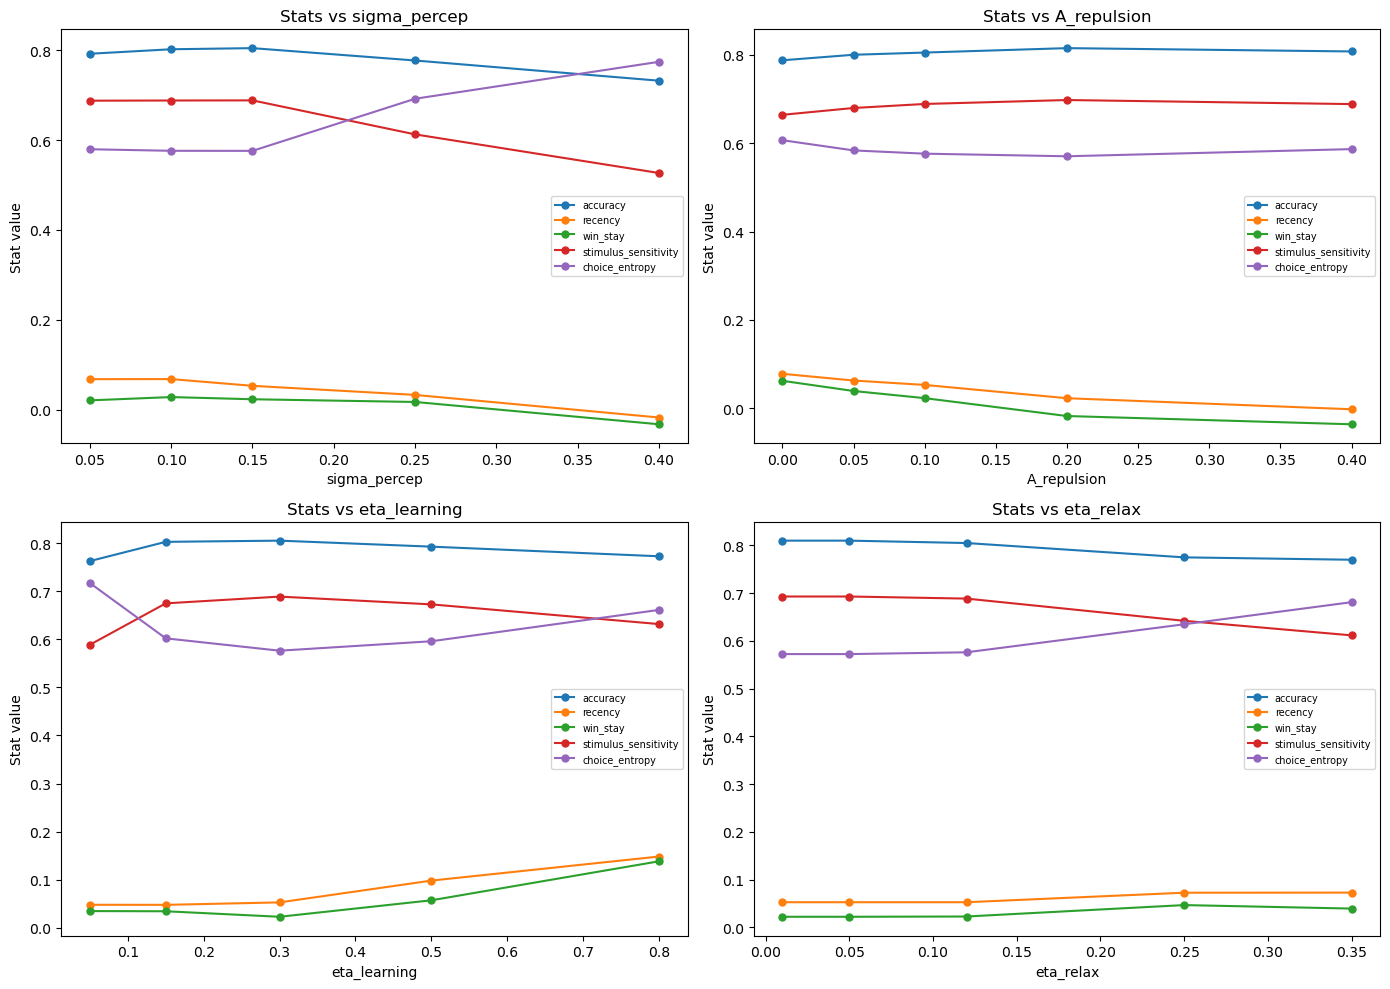

In [76]:
# --- Summary stats across sweeps ---
stat_names_for_sweep = ['accuracy', 'recency', 'win_stay', 'stimulus_sensitivity', 'choice_entropy']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, pname in zip(axes.flat, sweeps.keys()):
    results = sweep_results[pname]
    vals = [r['value'] for r in results]
    
    for sname in stat_names_for_sweep:
        stat_vals = []
        for res in results:
            valid = ~np.isnan(res['choices'])
            s = compute_summary_stats(
                res['choices'][valid], res['stimuli'][valid], res['categories'][valid],
                stat_names=[sname], return_dict=True,
            )
            # Handle dict returns (psychometric)
            if isinstance(s[sname], dict):
                stat_vals.append(list(s[sname].values())[0])
            else:
                stat_vals.append(float(s[sname]))
        
        ax.plot(vals, stat_vals, 'o-', linewidth=1.5, markersize=5, label=sname)
    
    ax.set_xlabel(pname)
    ax.set_ylabel('Stat value')
    ax.set_title(f'Stats vs {pname}')
    ax.legend(fontsize=7)

plt.tight_layout()
plt.show()

## 4. Multi-Session Trajectories

Generate synthetic animals with full learning trajectories and
visualise how behaviour evolves across sessions.

In [77]:
# --- 4a. Naive -> Expert (simple) ---
N_SESSIONS = 25
params_simple = param_trajectory_naive_to_expert(N_SESSIONS)

animal_simple, gt_simple = generate_synthetic_animal(
    animal_id='SYN_SIMPLE',
    true_params=params_simple,
    trials_per_session=300,
    seed=42,
)

print(f"Generated {animal_simple.n_sessions} sessions")
print(f"eta trajectory: {[f'{e:.3f}' for e in gt_simple['params_per_session']['eta_learning'][:5]]} "
      f"... {[f'{e:.3f}' for e in gt_simple['params_per_session']['eta_learning'][-3:]]}")

Generated 25 sessions
eta trajectory: ['0.450', '0.408', '0.371', '0.338', '0.309'] ... ['0.106', '0.103', '0.101']


In [78]:
# --- Performance and key stats across sessions ---
from Analysis.summary_stats import compute_summary_stats

def compute_trajectory_stats(animal, gt, stat_names=None):
    """Compute stats per session for a synthetic animal."""
    if stat_names is None:
        stat_names = ['accuracy', 'psychometric', 'recency', 'win_stay',
                      'stimulus_sensitivity', 'choice_entropy']
    
    results = {'session_idx': [], 'eta_learning': [], 'distribution': []}
    # Initialise stat columns
    example = compute_summary_stats(
        np.array([0,1,0,1.0]), np.array([-0.5,0.5,-0.3,0.3]),
        np.array([0,1,0,1]), stat_names=stat_names, return_dict=True
    )
    for sname, val in example.items():
        if isinstance(val, dict):
            for k in val:
                results[k] = []
        else:
            results[sname] = []
    
    for s_idx, session in enumerate(animal.sessions):
        arrays = session.trials.get_model_arrays(exclude_abort=True, exclude_opto=True)
        valid = ~arrays['no_response']
        
        results['session_idx'].append(s_idx)
        results['eta_learning'].append(gt['params_per_session']['eta_learning'][s_idx])
        results['distribution'].append(session.distribution)
        
        stats = compute_summary_stats(
            arrays['choices'][valid], arrays['stimuli'][valid], arrays['categories'][valid],
            stat_names=stat_names, return_dict=True
        )
        for sname, val in stats.items():
            if isinstance(val, dict):
                for k, v in val.items():
                    results[k].append(float(v))
            else:
                results[sname].append(float(val))
    
    return {k: np.array(v) for k, v in results.items()}

traj_simple = compute_trajectory_stats(animal_simple, gt_simple)

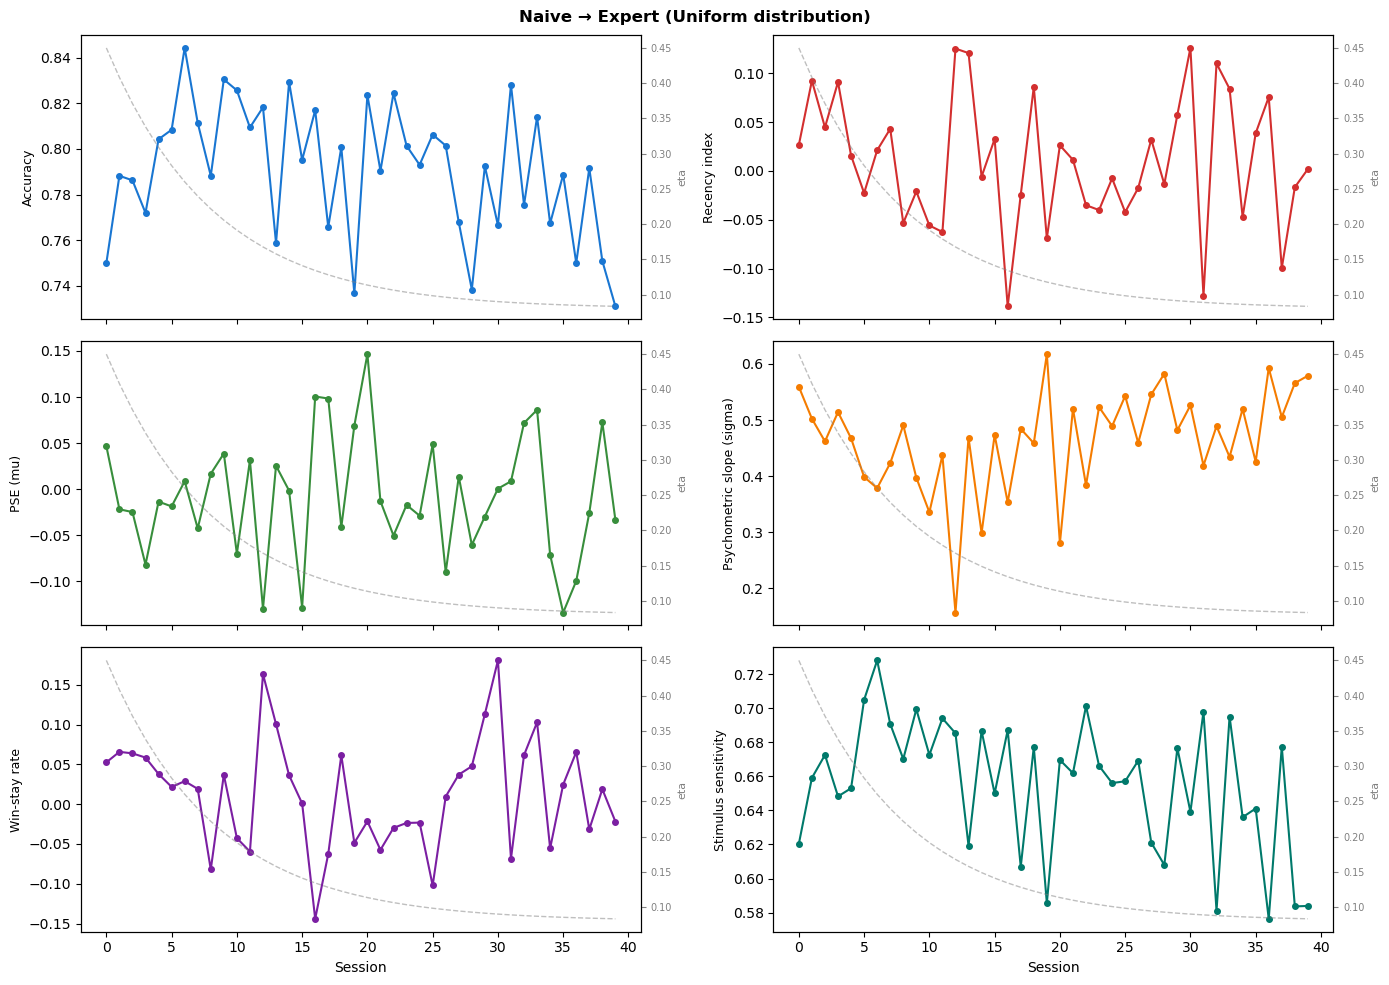

In [62]:
# --- Plot trajectory ---
def plot_trajectory(traj, title='', dist_changes=None):
    """Plot key stats across sessions with eta overlay."""
    fig, axes = plt.subplots(3, 2, figsize=(14, 10), sharex=True)
    s = traj['session_idx']
    
    plots = [
        ('accuracy', 'Accuracy', '#1976d2'),
        ('recency', 'Recency index', '#d32f2f'),
        ('pse', 'PSE (mu)', '#388e3c'),
        ('slope', 'Psychometric slope (sigma)', '#f57c00'),
        ('win_stay', 'Win-stay rate', '#7b1fa2'),
        ('stimulus_sensitivity', 'Stimulus sensitivity', '#00796b'),
    ]
    
    for ax, (key, label, color) in zip(axes.flat, plots):
        if key in traj:
            ax.plot(s, traj[key], 'o-', color=color, linewidth=1.5, markersize=4, label=label)
            ax.set_ylabel(label, fontsize=9)
        
        # Overlay eta on twin axis
        ax2 = ax.twinx()
        ax2.plot(s, traj['eta_learning'], '--', color='grey', alpha=0.5, linewidth=1)
        ax2.set_ylabel('eta', color='grey', fontsize=8)
        ax2.tick_params(axis='y', colors='grey', labelsize=7)
        
        # Mark distribution changes
        if dist_changes:
            for dc in dist_changes:
                ax.axvline(dc, color='red', linewidth=1, linestyle=':', alpha=0.7)
    
    axes[-1, 0].set_xlabel('Session')
    axes[-1, 1].set_xlabel('Session')
    fig.suptitle(title, fontsize=12, fontweight='bold')
    plt.tight_layout()
    return fig

fig = plot_trajectory(traj_simple, title='Naive → Expert (Uniform distribution)')
plt.show()

### 4b. Full trajectory: Naive → Expert → Distribution Shift

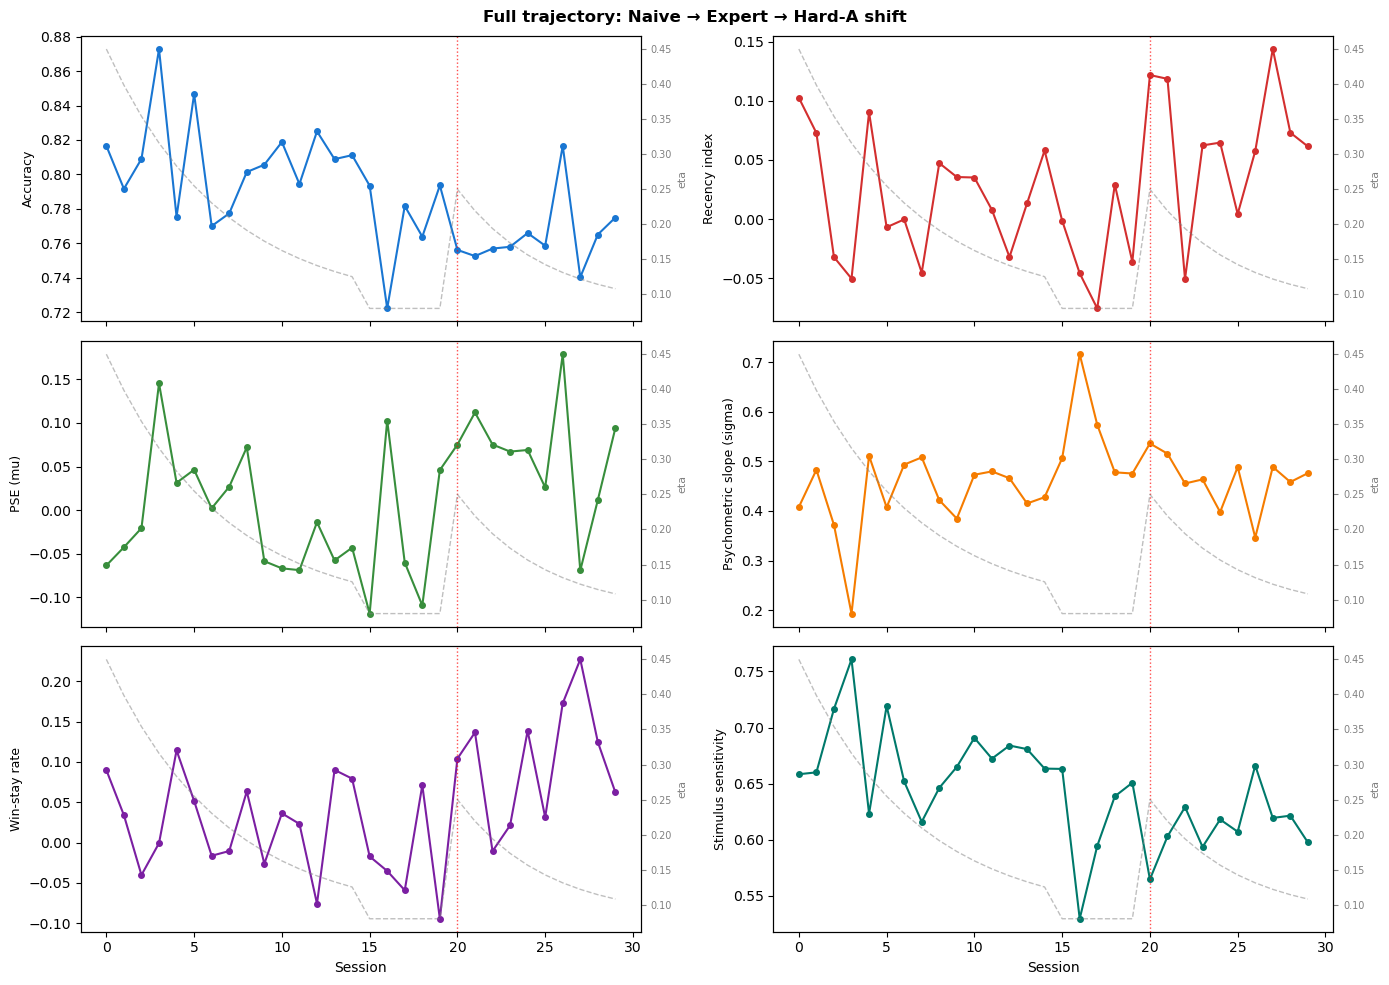

In [15]:
# --- Full trajectory with distribution shift ---
N_NAIVE, N_EXPERT, N_POST = 15, 5, 10
params_full = param_trajectory_full(
    n_sessions_naive=N_NAIVE,
    n_sessions_expert=N_EXPERT,
    n_sessions_post_shift=N_POST,
)
schedule_full = make_distribution_schedule([
    DistributionEpoch('Uniform', N_NAIVE + N_EXPERT),
    DistributionEpoch('Hard-A', N_POST),
])

animal_full, gt_full = generate_synthetic_animal(
    animal_id='SYN_FULL',
    true_params=params_full,
    distribution_schedule=schedule_full,
    trials_per_session=300,
    seed=123,
)

traj_full = compute_trajectory_stats(animal_full, gt_full)
fig = plot_trajectory(
    traj_full,
    title='Full trajectory: Naive → Expert → Hard-A shift',
    dist_changes=[N_NAIVE + N_EXPERT],
)
plt.show()

## 5. Cycling Design: A→B→A→B with Meta-Learning

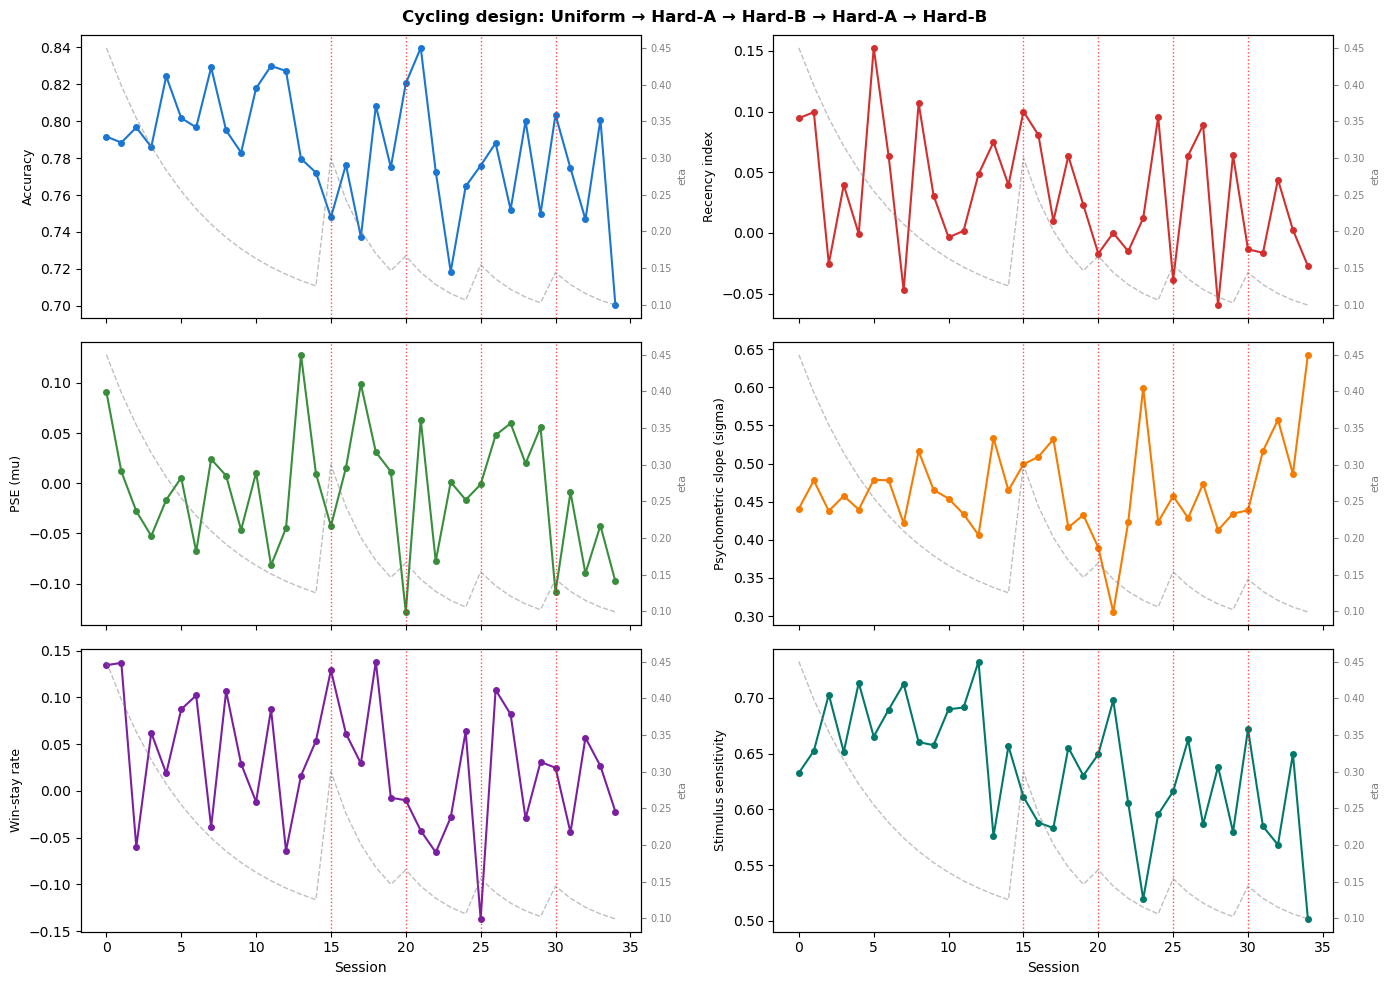

In [16]:
# --- Cycling design ---
N_BASELINE = 15
N_PER_CYCLE = 5
N_CYCLES = 4

params_cyc = param_trajectory_cycling(
    n_sessions_baseline=N_BASELINE,
    n_sessions_per_cycle=N_PER_CYCLE,
    n_cycles=N_CYCLES,
)
schedule_cyc = make_distribution_schedule([
    DistributionEpoch('Uniform', N_BASELINE),
    DistributionEpoch('Hard-A', N_PER_CYCLE),
    DistributionEpoch('Hard-B', N_PER_CYCLE),
    DistributionEpoch('Hard-A', N_PER_CYCLE),
    DistributionEpoch('Hard-B', N_PER_CYCLE),
])

animal_cyc, gt_cyc = generate_synthetic_animal(
    animal_id='SYN_CYCLE',
    true_params=params_cyc,
    distribution_schedule=schedule_cyc,
    trials_per_session=250,
    seed=456,
)

traj_cyc = compute_trajectory_stats(animal_cyc, gt_cyc)

# Mark all distribution transitions
shift_points = [N_BASELINE + i * N_PER_CYCLE for i in range(N_CYCLES)]
fig = plot_trajectory(
    traj_cyc,
    title='Cycling design: Uniform → Hard-A → Hard-B → Hard-A → Hard-B',
    dist_changes=shift_points,
)
plt.show()

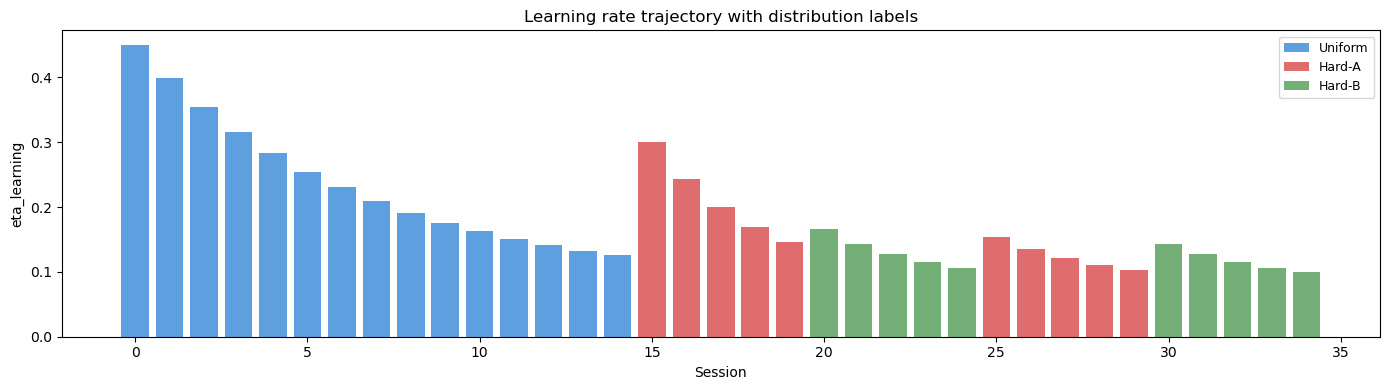

In [17]:
# --- Distribution labels per session ---
fig, ax = plt.subplots(figsize=(14, 4))
dists = traj_cyc['distribution']
eta = traj_cyc['eta_learning']
s = traj_cyc['session_idx']

dist_colors = {'Uniform': '#1976d2', 'Hard-A': '#d32f2f', 'Hard-B': '#388e3c'}

for i in range(len(s)):
    ax.bar(s[i], eta[i], color=dist_colors.get(dists[i], 'grey'), alpha=0.7, width=0.8)

ax.set_xlabel('Session')
ax.set_ylabel('eta_learning')
ax.set_title('Learning rate trajectory with distribution labels')

# Legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=c, alpha=0.7, label=d) for d, c in dist_colors.items()]
ax.legend(handles=legend_elements, fontsize=9)
plt.tight_layout()
plt.show()

## 6. Distribution Effects

Compare behaviour under Uniform, Hard-A, and Hard-B distributions
for the same model parameters. Shows how the stimulus distribution
shapes the psychometric curve and summary stats even without
any parameter changes.

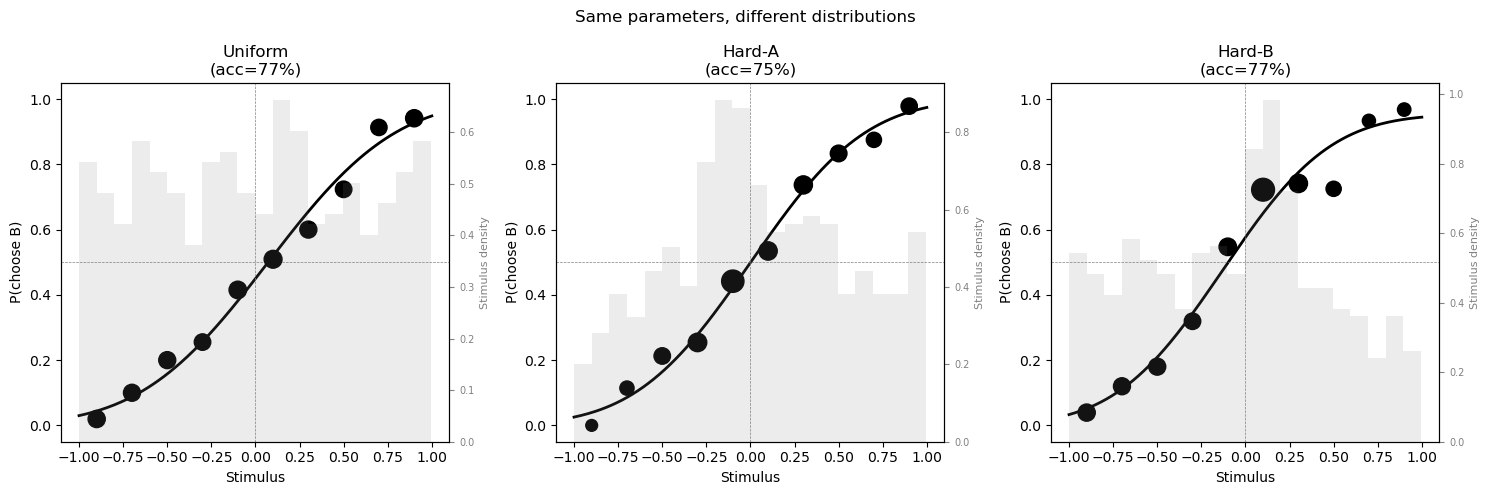

In [18]:
# --- Compare distributions with identical parameters ---
EXPERT_PARAMS = dict(sigma_percep=0.15, A_repulsion=0.10, eta_learning=0.10, eta_relax=0.12)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
x_fine = np.linspace(-1, 1, 200)

for ax, dist_name in zip(axes, ['Uniform', 'Hard-A', 'Hard-B']):
    model = BoundaryEstimationModel(**EXPERT_PARAMS)
    model.reset_belief(burn_in=1000)
    
    rng = np.random.default_rng(42)
    stim = sample_stimuli(500, dist_name, rng)
    cats = stimulus_to_category(stim)
    ch, pB = model.simulate_session(stim, cats, rng=rng)
    
    valid = ~np.isnan(ch)
    
    # Stimulus histogram
    ax2 = ax.twinx()
    ax2.hist(stim, bins=20, alpha=0.15, color='grey', density=True)
    ax2.set_ylabel('Stimulus density', color='grey', fontsize=8)
    ax2.tick_params(axis='y', colors='grey', labelsize=7)
    
    # Psychometric
    psych = fit_psychometric(stim[valid], ch[valid])
    if psych['success']:
        y_fit = cumulative_gaussian(x_fine, psych['mu'], psych['sigma'],
                                     psych['lapse_low'], psych['lapse_high'])
        ax.plot(x_fine, y_fit, 'k-', linewidth=2)
    
    # Binned data
    n_bins = 10
    be = np.linspace(-1, 1, n_bins + 1)
    mids = (be[:-1] + be[1:]) / 2
    bi = np.clip(np.digitize(stim[valid], be) - 1, 0, n_bins - 1)
    p_binned = [ch[valid][bi == b].mean() if (bi == b).sum() > 0 else np.nan for b in range(n_bins)]
    n_binned = [(bi == b).sum() for b in range(n_bins)]
    ax.scatter(mids, p_binned, s=[n*3 for n in n_binned], c='k', zorder=3)
    
    ax.axhline(0.5, color='grey', linewidth=0.5, linestyle='--')
    ax.axvline(0, color='grey', linewidth=0.5, linestyle='--')
    ax.set_xlabel('Stimulus')
    ax.set_ylabel('P(choose B)')
    correct_i = (ch == cats)
    valid_i = ~np.isnan(ch)
    ax.set_title(f'{dist_name}\n(acc={correct_i[valid_i].mean():.0%})')
    ax.set_ylim(-0.05, 1.05)

plt.suptitle('Same parameters, different distributions', fontsize=12)
plt.tight_layout()
plt.show()

---

**Next:** `2_stat_param_sensitivity.ipynb` — Which summary statistics are informative
about which model parameters, and which stats track learning?